In [57]:
%pip install composable

Note: you may need to restart the kernel to use updated packages.


In [115]:
import polars as pl
import polars.selectors as cs
import numpy as np
from toolz.dicttoolz import valmap
from composable import pipeable
from composable.strict import map
import composable.records as rec
from composable.object import obj, attr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor   

## Comparing two or more models cross validation

Next, we look at comparing two models' performance using cross-validation.

## Proper cross validation on multiple models

- **Bias**: Different shuffles of the data can lead to different results
- **Unbiased**: Use the same shuffle of data for all models

### The problem - Difference shuffles for different models

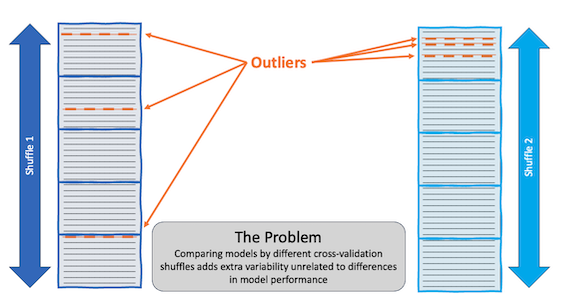

### The solution - Use the same shuffle to compare all models

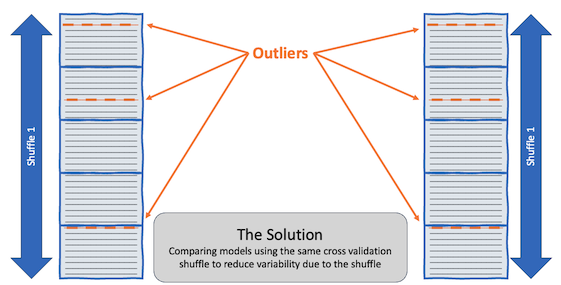


## Using the same shuffle to compare models in `sklearn`

There are two ways to ensure that the same shuffle is used for all models in `sklearn`:

1. **Easier but annoying.** Create a `KFold` object and pass it to `cross_val_score` or `GridSearchCV` for each model, or
2. **More elegant but complex.** Abstract the grid search to include the model as a parameter, and use `GridSearchCV` to compare all models at once.

### Easy but annoying way to ensure the same shuffle is used for all models in `sklearn`

- Create a `KFold` object with a specified random seed
- Pass the `KFold` object to `cross_val_score` or `GridSearchCV` for each model
- Ensures identical data splits for each model
- Allows fair comparison of model performance

### More elegant but complex way to ensure the same shuffle is used for all models in `sklearn`

* Create a pipeline that includes the model as a step using `TransformedTargetRegressor`
* Build a list of parameter grids, one for each model.
* Use `GridSearchCV` to compare all models at once, ensuring the same shuffle is used for each model.

## Cross validation for regression

### Home prices data set

For this exercise, we will be using the `HomePrices.csv` data set that I use in STAT 310, which is available in the `data` folder.

In [116]:
homes = pl.read_csv('./data/HomePrices.csv')
X_homes = homes.drop('CurrentPrice').to_pandas()
y_homes = homes.get_column('CurrentPrice').to_numpy()

homes

MLS,CurrentPrice,SquareFeet,Bedrooms,Bathrooms,Garage,YearBuilt,LotSize,Taxes,DaysonMarket,OriginalPrice
i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64
4036305,119900,1936,3,2.0,2,1920,7000,1448,151,129900
4034062,73700,1696,2,1.0,1,1916,6860,664,245,73700
4038971,104500,1196,3,2.0,2,1890,7000,1216,51,104500
4034561,114900,864,2,1.0,2,1940,5000,1092,218,114900
4035526,215000,3300,4,3.0,2,2001,null,2850,174,215000
…,…,…,…,…,…,…,…,…,…,…
4039546,119000,1056,2,2.0,1,1977,1848,1364,23,119000
4039325,104900,1992,3,1.0,0,1890,4800,1516,35,104900
4037376,139500,1314,2,2.0,2,1995,6600,1694,160,149500


#### Model 1 - Linear regression with all predictors

In [117]:
(model_LR :=
 make_pipeline(SimpleImputer(),
               LinearRegression()
               )
)

,steps,"[('simpleimputer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,fit_intercept,True


In [118]:
(grid_LR :=
 {'linearregression__fit_intercept': [True, False],
 }
)

{'linearregression__fit_intercept': [True, False]}

#### Model 2 KNN regression with all predictors

In [119]:
(model_kNN :=
 make_pipeline(SimpleImputer(), 
               StandardScaler(), 
               KNeighborsRegressor())
)

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [120]:
(grid_kNN :=
 {'kneighborsregressor__n_neighbors': [2,3,4, 5]}
)

{'kneighborsregressor__n_neighbors': [2, 3, 4, 5]}

## Demonstration of Approach 1 - Using `KFold` with a random seed

* Create a `KFold` object with a specified random seed
* Pass the `KFold` object to `cross_val_score`, `cross_validate`, or `GridSearchCV` for each model

#### Step 1 - Create a `KFold` object with a specified random seed

In [121]:
(folds :=
 KFold(n_splits=5, shuffle=True, random_state=2079)
)

KFold(n_splits=5, random_state=2079, shuffle=True)

#### Step 2 - Pass the `KFold` object to `cross_val_score`, `cross_validate` or `GridSearchCV` for each model

#### A single score with `cross_val_score` 

In [122]:
(single_cv_mspe :=
    {'LR': cross_val_score(model_LR, X_homes, y_homes, cv = folds, scoring='neg_mean_squared_error'),
     'kNN': cross_val_score(model_kNN, X_homes, y_homes, cv = folds, scoring='neg_mean_squared_error')
    }
)

{'LR': array([-1.15750440e+08, -6.17043899e+07, -1.59612034e+08, -2.40990242e+08,
        -1.36900957e+08]),
 'kNN': array([-4.03315490e+08, -3.82617002e+08, -7.49932967e+08, -1.21057266e+09,
        -7.88354593e+08])}

In [123]:
(single_cv_mspe 
 >> rec.map(np.mean) 
 >> rec.map(lambda x: (-1*x)**0.5)
)

{'LR': np.float64(11957.91004416899), 'kNN': np.float64(26588.6920131811)}

In [124]:
# Refactor to clean up the replicated code
get_single_mspe = lambda m: cross_val_score(m, X_homes, y_homes, cv = folds, scoring='neg_mean_squared_error')

(single_cv_mspe :=
    {'LR': get_single_mspe(model_LR),
     'kNN': get_single_mspe(model_kNN),
    }
)


{'LR': array([-1.15750440e+08, -6.17043899e+07, -1.59612034e+08, -2.40990242e+08,
        -1.36900957e+08]),
 'kNN': array([-4.03315490e+08, -3.82617002e+08, -7.49932967e+08, -1.21057266e+09,
        -7.88354593e+08])}

#### Multiple scores with `cross_validate`

In [125]:
scoring = ['explained_variance', 
           'neg_mean_absolute_error', 
           'neg_mean_squared_error']

get_cv_scores = lambda m: cross_validate(m, X_homes, y_homes, cv=folds, scoring=scoring)

(cv_scores :=
    {'LR': get_cv_scores(model_LR),
     'kNN': get_cv_scores(model_kNN),
    }

)


{'LR': {'fit_time': array([0.00789809, 0.00636005, 0.00361204, 0.00684547, 0.00356579]),
  'score_time': array([0.00415325, 0.00309157, 0.00584793, 0.00254941, 0.00207639]),
  'test_explained_variance': array([0.96638803, 0.97701541, 0.94135431, 0.95828048, 0.96620827]),
  'test_neg_mean_absolute_error': array([ -7328.0001381 ,  -6255.2651265 ,  -9639.0705714 , -10224.96375196,
          -8978.39406043]),
  'test_neg_mean_squared_error': array([-1.15750440e+08, -6.17043899e+07, -1.59612034e+08, -2.40990242e+08,
         -1.36900957e+08])},
 'kNN': {'fit_time': array([0.00326061, 0.00334358, 0.00277019, 0.00280476, 0.00293612]),
  'score_time': array([0.00317001, 0.0025034 , 0.00239873, 0.00263047, 0.00260043]),
  'test_explained_variance': array([0.88941032, 0.85541822, 0.73420858, 0.81266357, 0.80345942]),
  'test_neg_mean_absolute_error': array([-15961.08571429, -13529.33333333, -20064.35609756, -22046.37560976,
         -17857.68292683]),
  'test_neg_mean_squared_error': array([-4.0

In [126]:
(cv_scores
 >> rec.map(rec.drop(['fit_time', 'score_time']))                           
 >> rec.map(rec.map(np.mean))                                                
 >> rec.map(rec.apply(                                                      
              test_neg_mean_absolute_error = lambda x: -1*x,        
              test_neg_mean_squared_error  = lambda x: (-1*x)**0.5  
              ))
)

{'LR': {'test_explained_variance': np.float64(0.9618492992349414),
  'test_neg_mean_absolute_error': np.float64(8485.138729680979),
  'test_neg_mean_squared_error': np.float64(11957.91004416899)},
 'kNN': {'test_explained_variance': np.float64(0.8190320190574469),
  'test_neg_mean_absolute_error': np.float64(17891.766736353078),
  'test_neg_mean_squared_error': np.float64(26588.6920131811)}}

#### Performing a grid search of the two models with `GridSearchCV`

In [127]:
make_grid_search = lambda m, p: GridSearchCV(m, p, scoring='neg_mean_squared_error', verbose = 3, n_jobs=-1, cv = folds)

(grid_search_LR :=
 make_grid_search(model_LR, grid_LR)
 .fit(X_homes, y_homes)
)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [128]:
grid_search_LR.best_params_, grid_search_LR.best_score_

({'linearregression__fit_intercept': False}, np.float64(-140289339.9329694))

In [129]:
(grid_search_kNN :=
 make_grid_search(model_kNN, grid_kNN)
 .fit(X_homes, y_homes)
)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'kneighborsregressor__n_neighbors': [2, 3, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [130]:
grid_search_kNN.best_params_, grid_search_kNN.best_score_

({'kneighborsregressor__n_neighbors': 5}, np.float64(-706958542.9718003))

In [131]:
make_and_fit_grid_search = lambda m, p: GridSearchCV(m, p, scoring='neg_mean_squared_error', verbose = 3, n_jobs=-1, cv = folds).fit(X_homes, y_homes)

(grid_searches :=
 {'LR': make_and_fit_grid_search(model_LR, grid_LR),
  'kNN': make_and_fit_grid_search(model_kNN, grid_kNN)
 }
)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'LR': GridSearchCV(cv=KFold(n_splits=5, random_state=2079, shuffle=True),
              estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                        ('linearregression',
                                         LinearRegression())]),
              n_jobs=-1,
              param_grid={'linearregression__fit_intercept': [True, False]},
              scoring='neg_mean_squared_error', verbose=3),
 'kNN': GridSearchCV(cv=KFold(n_splits=5, random_state=2079, shuffle=True),
              estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                        ('standardscaler', StandardScaler()),
                                        ('kneighborsregressor',
                                         KNeighborsRegressor())]),
              n_jobs=-1,
              param_grid={'kneighborsregressor__n_neighbors': [2, 3, 4, 5]},
              scoring='neg_mean_squared_error', verbose=3)}

In [132]:
(best_params :=
 grid_searches
 >> rec.map(attr.best_params_)
)


{'LR': {'linearregression__fit_intercept': False},
 'kNN': {'kneighborsregressor__n_neighbors': 5}}

In [133]:
(best_scores :=
 grid_searches
 >> rec.map(attr.best_score_)
)

{'LR': np.float64(-140289339.9329694), 'kNN': np.float64(-706958542.9718003)}

## <font color="red"> Exercise 2.6.2 </font>

The `alligator_length_weight.csv` data set involves predicting the weight of an alligator based on its length.

**Tasks.**
1. Visualize the relationship between `Length` and `Weight` using a `sns.lmplot`.
2. Identify any preprocessing steps that may be necessary before fitting a regression model to this data.
3. Build a pipeline for each model to predict `Weight` from `Length` using the following approaches:
   - A linear regression model, and
   - A KNN regression model.
4. Perform a grid search to find the best tuning parameters for each model, and compare the performance of the two models using cross validation with all the metrics/techniques illustrated above.  Determine which model is "best" and explain your choice.

In [134]:
# Your code here (add cells as needed)
(gator := pl.read_csv('./data/alligator_length_weight.csv')).head()

Length (in),Weight (lb)
i64,i64
58,28
61,44
63,33
68,39
69,36


In [135]:
import seaborn as sns
import matplotlib.pyplot as plt 

<Axes: xlabel='Length (in)', ylabel='Weight (lb)'>

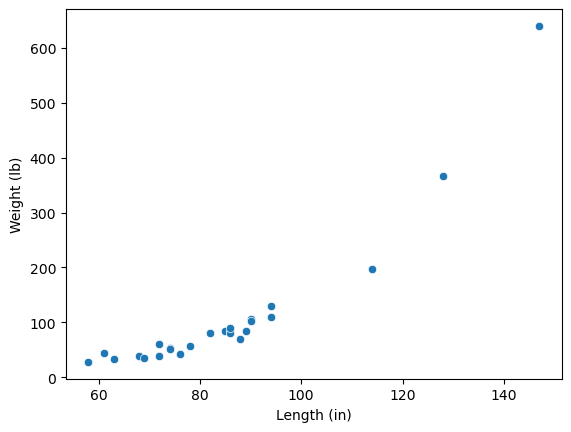

In [136]:
sns.scatterplot(data=gator.to_pandas(), x='Length (in)', y='Weight (lb)')
# Very quadratic curve, as expected with length and weight.

In [137]:
(X_gator:= gator.drop('Weight (lb)').to_pandas()).head()

,Length (in)
0,58
1,61
2,63
3,68
4,69


In [138]:
(y_gator := gator.get_column('Weight (lb)').to_numpy())

array([ 28,  44,  33,  39,  36,  38,  61,  54,  51,  42,  57,  80,  84,
        83,  80,  90,  70,  84, 106, 102, 110, 130, 197, 366, 640])

### will use standard scalar due to exponential nature of length and weight

In [139]:
#linear model with polynomial features
(linear_model :=
    make_pipeline(SimpleImputer(),
                  PolynomialFeatures(),
                  StandardScaler(),
               LinearRegression()
               )
)

,steps,"[('simpleimputer', ...), ('polynomialfeatures', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,degree,2


In [140]:
(KNN_model :=
    make_pipeline(SimpleImputer(), 
               StandardScaler(), 
               KNeighborsRegressor())
)

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [142]:
linear_params = {
'polynomialfeatures__degree': [1, 2, 3],
'linearregression__fit_intercept': [True, False]}

In [143]:
kfold = KFold(n_splits=5, shuffle=True, random_state=2948)

In [144]:
# Grid Search for Linear Regression
linear_grid = GridSearchCV(
    linear_model,
    param_grid=linear_params,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
linear_grid.fit(X_gator, y_gator)

,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False], 'polynomialfeatures__degree': [1, 2, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,missing_values,nan


In [145]:
knn_params = {
    'kneighborsregressor__n_neighbors': [3, 5, 7, 9, 11, 15, 20],  # note the name
    'kneighborsregressor__weights': ['uniform', 'distance']
}

In [146]:
knn_grid = GridSearchCV(
    KNN_model,
    param_grid=knn_params,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)
knn_grid.fit(X_gator, y_gator)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'kneighborsregressor__n_neighbors': [3, 5, ...], 'kneighborsregressor__weights': ['uniform', 'distance']}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,missing_values,nan


In [147]:
scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']

# Cross-validate the BEST models from grid search
(linear_cv := cross_validate(
    linear_grid.best_estimator_,
    X_gator, y_gator,
    cv=kfold,
    scoring=scoring
))

{'fit_time': array([0.00813389, 0.00803947, 0.00801182, 0.00505376, 0.00505185]),
 'score_time': array([0.00553298, 0.00529075, 0.00514078, 0.00454569, 0.00216007]),
 'test_neg_mean_absolute_error': array([-22.84447997, -62.1747632 ,  -7.17531376,  -7.57471053,
         -9.42666126]),
 'test_neg_mean_squared_error': array([  -828.39025307, -10186.95320509,    -54.46189917,    -98.9035353 ,
          -156.99032375]),
 'test_r2': array([0.79291072, 0.80329206, 0.89233374, 0.60055115, 0.60846388])}

In [148]:
(knn_cv := cross_validate(
    knn_grid.best_estimator_,
    X_gator, y_gator,
    cv=kfold,
    scoring=scoring
))

{'fit_time': array([0.0076282 , 0.00629067, 0.00478578, 0.00625086, 0.00463176]),
 'score_time': array([0.00313187, 0.003443  , 0.0056994 , 0.002702  , 0.00740719]),
 'test_neg_mean_absolute_error': array([ -16.54519451, -141.66268185,   -4.05      ,   -9.70002499,
         -13.71333333]),
 'test_neg_mean_squared_error': array([-3.14883325e+02, -5.55124974e+04, -3.11125000e+01, -1.57212194e+02,
        -3.07444222e+02]),
 'test_r2': array([ 0.92128232, -0.07193471,  0.9384934 ,  0.36505576,  0.23322969])}

In [149]:
(linear_mae := linear_cv['test_neg_mean_absolute_error'].mean())


np.float64(-21.839185744902384)

In [150]:
(linear_mse := linear_cv['test_neg_mean_squared_error'].mean())

np.float64(-2265.1398432783444)

In [151]:
(linear_r2 := linear_cv['test_r2'].mean())

np.float64(0.7395103110632422)

In [152]:
(knn_mae := knn_cv['test_neg_mean_absolute_error'].mean())

np.float64(-37.13424693515622)

In [153]:
(knn_mse := knn_cv['test_neg_mean_squared_error'].mean())

np.float64(-11264.629936981095)

In [154]:
(knn_r2 := knn_cv['test_r2'].mean())

np.float64(0.4772252906041798)

<font color="orange">
    The linear model originally performed worse but with adding polynomial features added ther linear performs significantly better then the kNN in all scoring aspects. So in conclusion when adding the polynomial features to the linear model since the data looks like a quadratic relationship the linear performs and predicts better overall and I would choose the linear model to predict weight off length. I would use the linear model if going the other way with predicting weight off length.
</font>